In [3]:
# needed libraries :

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import math
import plotly.express as px
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler


In [4]:
# Load the dataset

df = pd.read_csv("csv files/initial_data_renamed.csv")

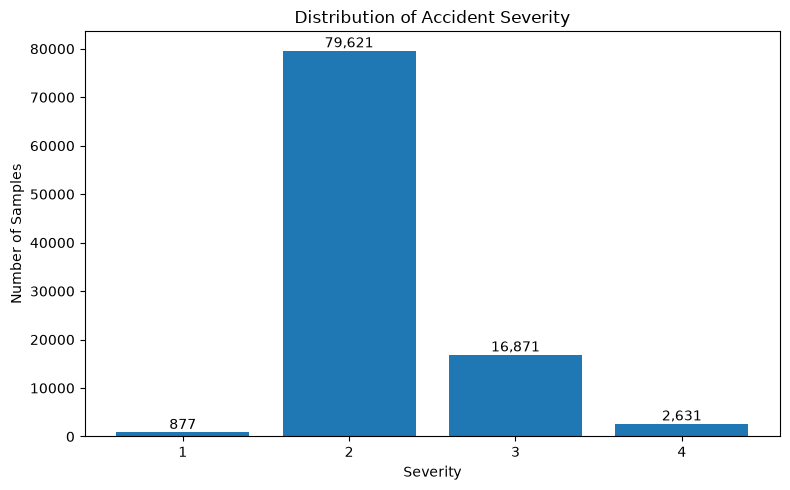

In [5]:
# y histogram :

y_counts = df["y"].value_counts().sort_index()

# Plot target distribution
plt.figure(figsize=(8, 5))
bars = plt.bar(y_counts.index.astype(str), y_counts.values)

plt.title("Distribution of Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Samples")

# Show counts above bars
for bar, count in zip(bars, y_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [6]:
# Split Data into train, validation and test

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["y"],
    random_state=42
)

# Split temporary set into validation and test sets
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["y"],
    random_state=42
)

# Reset indices
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Show dataset sizes
print(f"Train size: {len(train_df):,} ({len(train_df) / len(df):.0%})")
print(f"Validation size: {len(validation_df):,} ({len(validation_df) / len(df):.0%})")
print(f"Test size: {len(test_df):,} ({len(test_df) / len(df):.0%})")

# Compare target distributions
distribution_comparison = pd.DataFrame({
    "Full Data": df["y"].value_counts(normalize=True).sort_index(),
    "Train": train_df["y"].value_counts(normalize=True).sort_index(),
    "Validation": validation_df["y"].value_counts(normalize=True).sort_index(),
    "Test": test_df["y"].value_counts(normalize=True).sort_index()
}).mul(100).round(2)

print("\nTarget distribution percentages:")
display(distribution_comparison)

Train size: 70,000 (70%)
Validation size: 15,000 (15%)
Test size: 15,000 (15%)

Target distribution percentages:


,Full Data,Train,Validation,Test
y,,,,
1,0.88,0.88,0.87,0.88
2,79.62,79.62,79.63,79.62
3,16.87,16.87,16.87,16.87
4,2.63,2.63,2.63,2.63


we split the dataset into three parts: `train`, `validation`, and `test`.

The split was performed while preserving the distribution of the target variable `y` in all three sets.

This step was done early to prevent data leakage during the following processes, such as missing data handling and feature engineering. All decisions and transformations in later steps will be based only on the training data.



## Missing Data Handling

In [7]:
print("\nMissing values summary:")
missing_summary = pd.DataFrame({
    "missing_count": train_df.isna().sum(),
    "missing_percent": train_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary)


Missing values summary:


,missing_count,missing_percent
Lat,30735,43.907143
Lng,30735,43.907143
f20,20198,28.854286
f19,5252,7.502857
Wind_Direction,1576,2.251429
f16,1531,2.187143
f17,1263,1.804286
Weather_Time,1058,1.511429
Airport_Code,218,0.311429
f32,196,0.280000


### Decision about `Lat` , `Lng` :

plotting them on the map:

In [8]:
# Prepare location data from the training set
map_df = train_df[["Lat", "Lng", "y"]].copy()

# Convert coordinates to numeric
map_df["Lat"] = pd.to_numeric(map_df["Lat"], errors="coerce")
map_df["Lng"] = pd.to_numeric(map_df["Lng"], errors="coerce")
map_df["y"] = pd.to_numeric(map_df["y"], errors="coerce")

# Drop rows with missing coordinates or target
map_df = map_df.dropna(subset=["Lat", "Lng", "y"])

# Plot accident locations by severity
fig = px.scatter_geo(
    map_df,
    lon="Lng",
    lat="Lat",
    color="y",
    scope="usa",
    color_continuous_scale="Blues",
    range_color=[1, 4],
    title="Geographical Distribution of Accidents by Severity",
    labels={
        "Lng": "Longitude",
        "Lat": "Latitude",
        "y": "Accident Severity"
    },
    hover_data={
        "Lat": ":.4f",
        "Lng": ":.4f",
        "y": True
    }
)

fig.update_traces(
    marker={
        "size": 5,
        "opacity": 0.6
    }
)

fig.update_coloraxes(
    colorbar={
        "title": "Severity",
        "tickvals": [1, 2, 3, 4],
        "ticktext": ["1", "2", "3", "4"]
    }
)

fig.update_geos(
    showland=True,
    showlakes=True,
    showcountries=True,
    showsubunits=True
)

fig.show()

Checking that whether having `Lat-Lng` effects on `y` or not

By plotting:

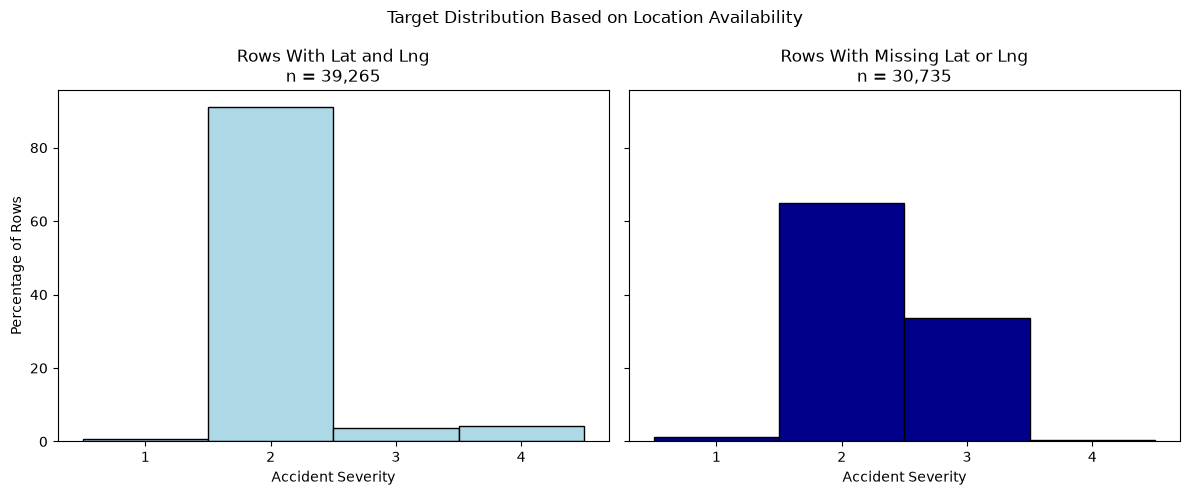

In [9]:
# Prepare location and target data
location_df = train_df[["Lat", "Lng", "y"]].copy()

# Convert columns to numeric
location_df["Lat"] = pd.to_numeric(location_df["Lat"], errors="coerce")
location_df["Lng"] = pd.to_numeric(location_df["Lng"], errors="coerce")
location_df["y"] = pd.to_numeric(location_df["y"], errors="coerce")

# Separate rows by location availability
has_location = location_df["Lat"].notna() & location_df["Lng"].notna()

y_with_location = location_df.loc[has_location, "y"].dropna()
y_without_location = location_df.loc[~has_location, "y"].dropna()

# Define severity bins
severity_bins = [0.5, 1.5, 2.5, 3.5, 4.5]

# Plot normalized distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(
    y_with_location,
    bins=severity_bins,
    weights=[100 / len(y_with_location)] * len(y_with_location),
    edgecolor="black",
    color="lightblue"
)

axes[0].set_title(
    f"Rows With Lat and Lng\nn = {len(y_with_location):,}"
)
axes[0].set_xlabel("Accident Severity")
axes[0].set_ylabel("Percentage of Rows")
axes[0].set_xticks([1, 2, 3, 4])

axes[1].hist(
    y_without_location,
    bins=severity_bins,
    weights=[100 / len(y_without_location)] * len(y_without_location),
    edgecolor="black",
    color="darkblue"
)

axes[1].set_title(
    f"Rows With Missing Lat or Lng\nn = {len(y_without_location):,}"
)
axes[1].set_xlabel("Accident Severity")
axes[1].set_xticks([1, 2, 3, 4])

plt.suptitle("Target Distribution Based on Location Availability")
plt.tight_layout()
plt.show()

By Chi-Square:

In [10]:
# Prepare required columns
chi_df = train_df[["Lat", "Lng", "y"]].copy()

# Define location availability
chi_df["Location_Status"] = (
    chi_df["Lat"].notna() & chi_df["Lng"].notna()
).map({
    True: "Has Location",
    False: "Missing Location"
})

# Remove rows with missing target
chi_df = chi_df.dropna(subset=["y"])

# Create the contingency table
contingency_table = pd.crosstab(
    chi_df["Location_Status"],
    chi_df["y"]
).reindex(
    index=["Has Location", "Missing Location"],
    columns=[1, 2, 3, 4],
    fill_value=0
)

print("Contingency table:")
display(contingency_table)

# Calculate row percentages
percentage_table = contingency_table.div(
    contingency_table.sum(axis=1),
    axis=0
).mul(100).round(2)

print("Target distribution percentages:")
display(percentage_table)

# Run the Chi-Square test
chi2_stat, p_value, degrees_of_freedom, expected_counts = chi2_contingency(
    contingency_table
)

expected_table = pd.DataFrame(
    expected_counts,
    index=contingency_table.index,
    columns=contingency_table.columns
)

print(f"Chi-Square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.6f}")

print("\nExpected counts:")
display(expected_table.round(2))

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print(
        "Result: Reject H0. "
        "Location missingness and accident severity are associated."
    )
else:
    print(
        "Result: Fail to reject H0. "
        "There is not enough evidence of an association."
    )

# Check the Chi-Square assumption
if (expected_table < 5).any().any():
    print(
        "Warning: Some expected counts are below 5. "
        "The Chi-Square result may be unreliable."
    )

Contingency table:


y,1,2,3,4
Location_Status,,,,
Has Location,278,35795,1489,1703
Missing Location,336,19939,10321,139


Target distribution percentages:


y,1,2,3,4
Location_Status,,,,
Has Location,0.71,91.16,3.79,4.34
Missing Location,1.09,64.87,33.58,0.45


Chi-Square statistic: 11581.8448
Degrees of freedom: 3
P-value: 0.000000

Expected counts:


y,1,2,3,4
Location_Status,,,,
Has Location,344.41,31262.79,6624.57,1033.23
Missing Location,269.59,24471.21,5185.43,808.77


Result: Reject H0. Location missingness and accident severity are associated.


In [11]:
# Add location availability feature
for dataset in [train_df, validation_df, test_df]:
    dataset["Lat"] = pd.to_numeric(dataset["Lat"], errors="coerce")
    dataset["Lng"] = pd.to_numeric(dataset["Lng"], errors="coerce")

    dataset["Location_Available"] = (
        dataset["Lat"].notna() & dataset["Lng"].notna()
    ).astype("int8")

# Check the new feature
print("Train:")
print(train_df["Location_Available"].value_counts(dropna=False))

print("\nValidation:")
print(validation_df["Location_Available"].value_counts(dropna=False))

print("\nTest:")
print(test_df["Location_Available"].value_counts(dropna=False))

Train:
Location_Available
1    39265
0    30735
Name: count, dtype: int64

Validation:
Location_Available
1    8491
0    6509
Name: count, dtype: int64

Test:
Location_Available
1    8391
0    6609
Name: count, dtype: int64


In [12]:
# Drop coordinates after preserving missingness information
for dataset in [train_df, validation_df, test_df]:
    dataset.drop(columns=["Lat", "Lng"], inplace=True)


##### Handling Missing Geographical Information

Since more than 40% of the values in `Lat` and `Lng` were missing, we decided to remove these two columns.

Although geographical location can affect accident severity, this information can still be partially captured through features such as street name and city. On the other hand, filling around 43% of the missing values with estimated coordinates could introduce noise and negatively affect the model performance.

However, using the Chi-Square test, we found that the availability of geographical coordinates itself contains information about the target variable.

Therefore, instead of keeping `Lat` and `Lng`, we created a new binary feature:

`Location_Available`

- `1`: Latitude and Longitude are available
- `0`: Latitude and Longitude are missing


### Decision about `f16`, `f17`, `f19` and `f20` :

In [13]:
# A function that shows mean of numercial values base on mentioned states (we need it later)

def plot_state_feature_means(
    columns,
    data=train_df,
    state_col="State"
):
    # Validate the input
    if not isinstance(columns, (list, tuple)):
        raise TypeError("columns must be a list or tuple.")

    if state_col not in data.columns:
        raise ValueError(f"Column '{state_col}' does not exist.")

    missing_columns = [
        column for column in columns
        if column not in data.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Columns not found: {missing_columns}"
        )

    for column in columns:
        # Prepare required data
        plot_df = data[[state_col, column]].copy()

        # Convert feature to numeric
        plot_df[column] = pd.to_numeric(
            plot_df[column],
            errors="coerce"
        )

        # Remove missing values
        plot_df = plot_df.dropna(
            subset=[state_col, column]
        )

        if plot_df.empty:
            print(f"No valid data found for '{column}'.")
            continue

        # Calculate state means and counts
        state_summary = (
            plot_df
            .groupby(state_col)[column]
            .agg(["mean", "count"])
            .sort_values("mean")
        )

        # Calculate the overall mean
        overall_mean = plot_df[column].mean()

        # Set dynamic figure height
        figure_height = max(
            6,
            len(state_summary) * 0.28
        )

        # Plot state means
        plt.figure(figsize=(10, figure_height))

        bars = plt.barh(
            state_summary.index,
            state_summary["mean"],
            edgecolor="black",
            alpha=0.8
        )

        # Show the overall mean
        plt.axvline(
            overall_mean,
            linestyle="--",
            linewidth=2,
            label=f"Overall Mean: {overall_mean:.2f}"
        )

        # Show mean and sample count
        for bar, mean_value, count_value in zip(
            bars,
            state_summary["mean"],
            state_summary["count"]
        ):
            plt.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f" {mean_value:.2f} (n={count_value})",
                va="center",
                fontsize=8
            )

        plt.title(
            f"Mean of {column} by State"
        )
        plt.xlabel(f"Mean of {column}")
        plt.ylabel("State")
        plt.legend()
        plt.tight_layout()
        plt.show()

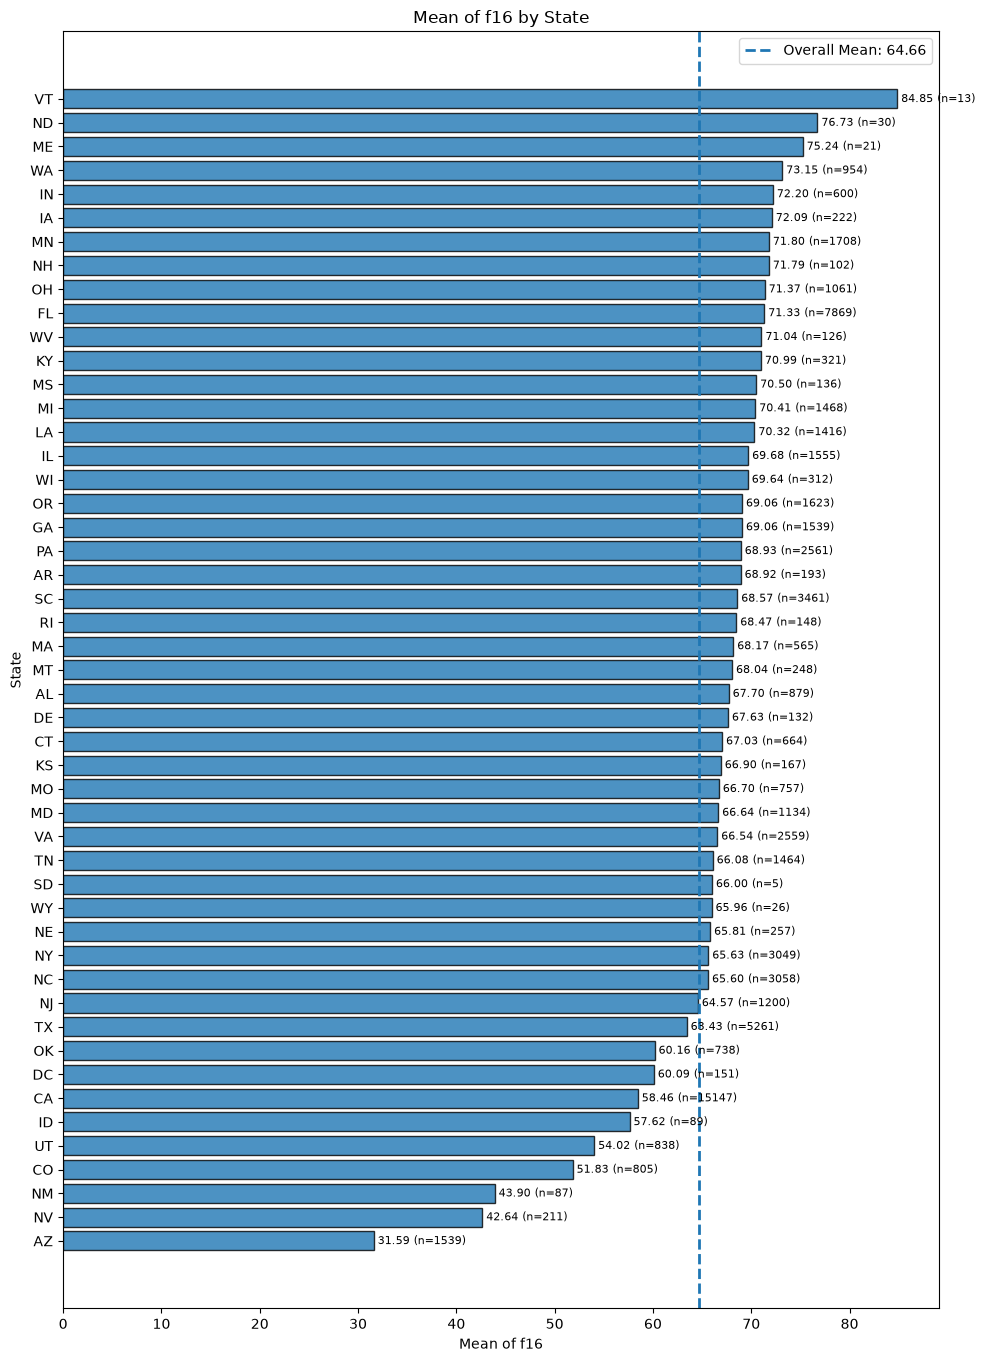

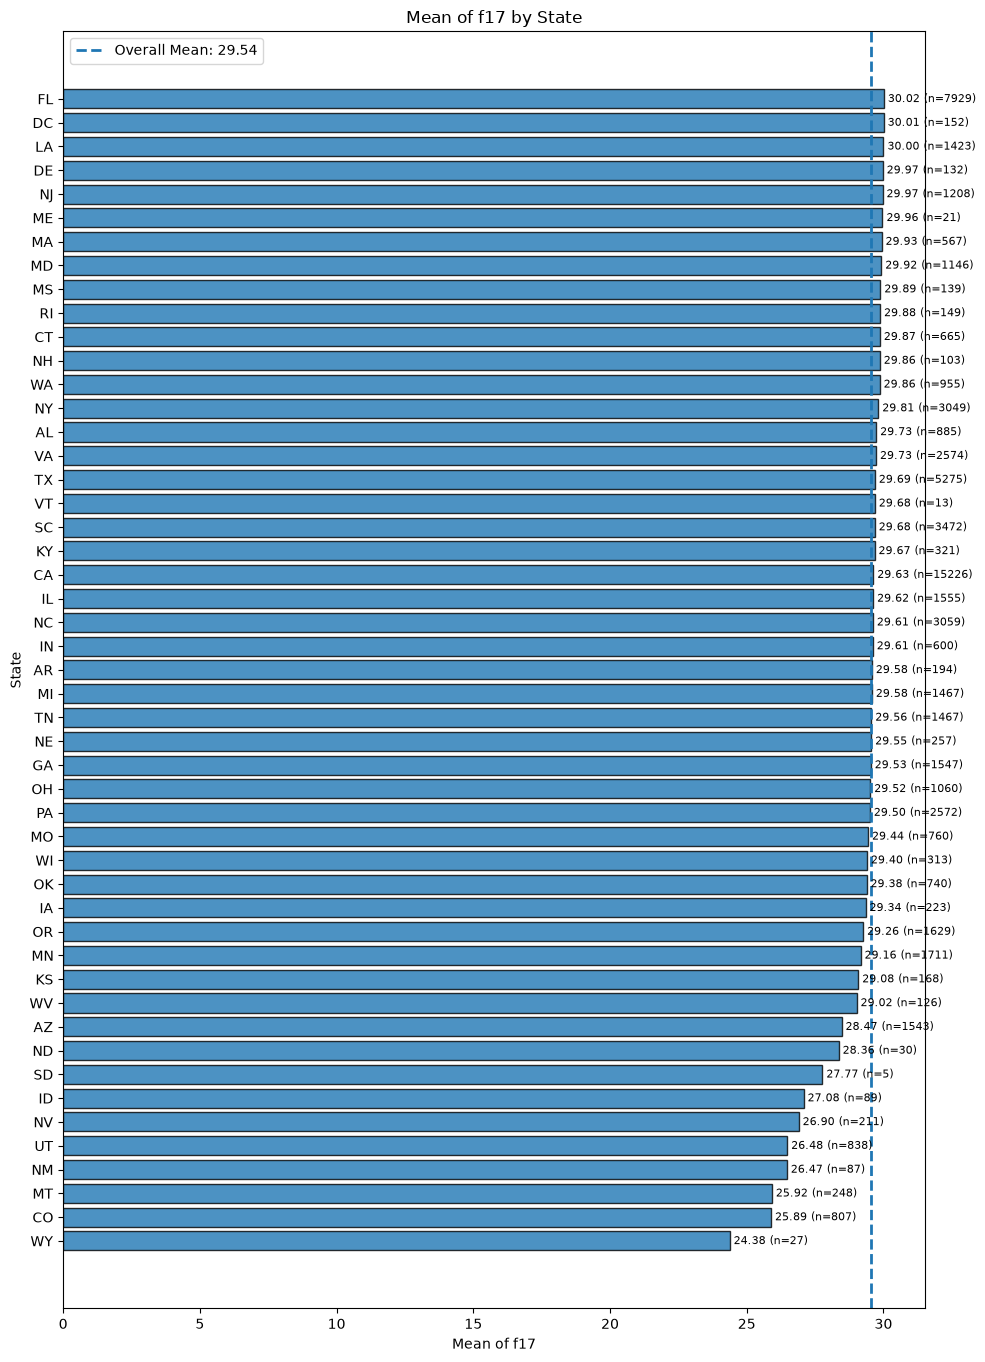

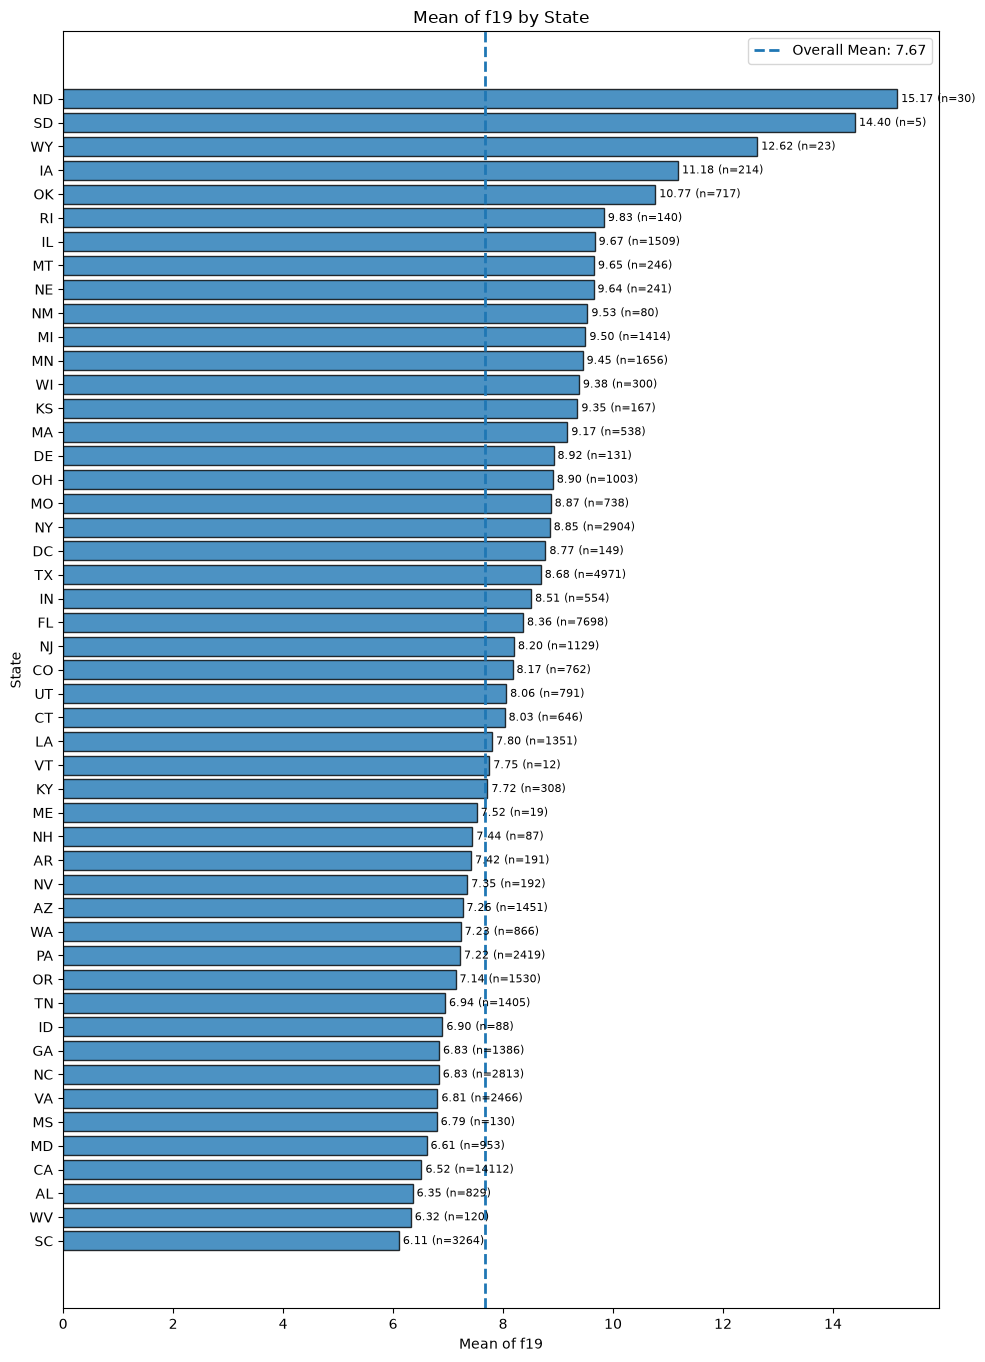

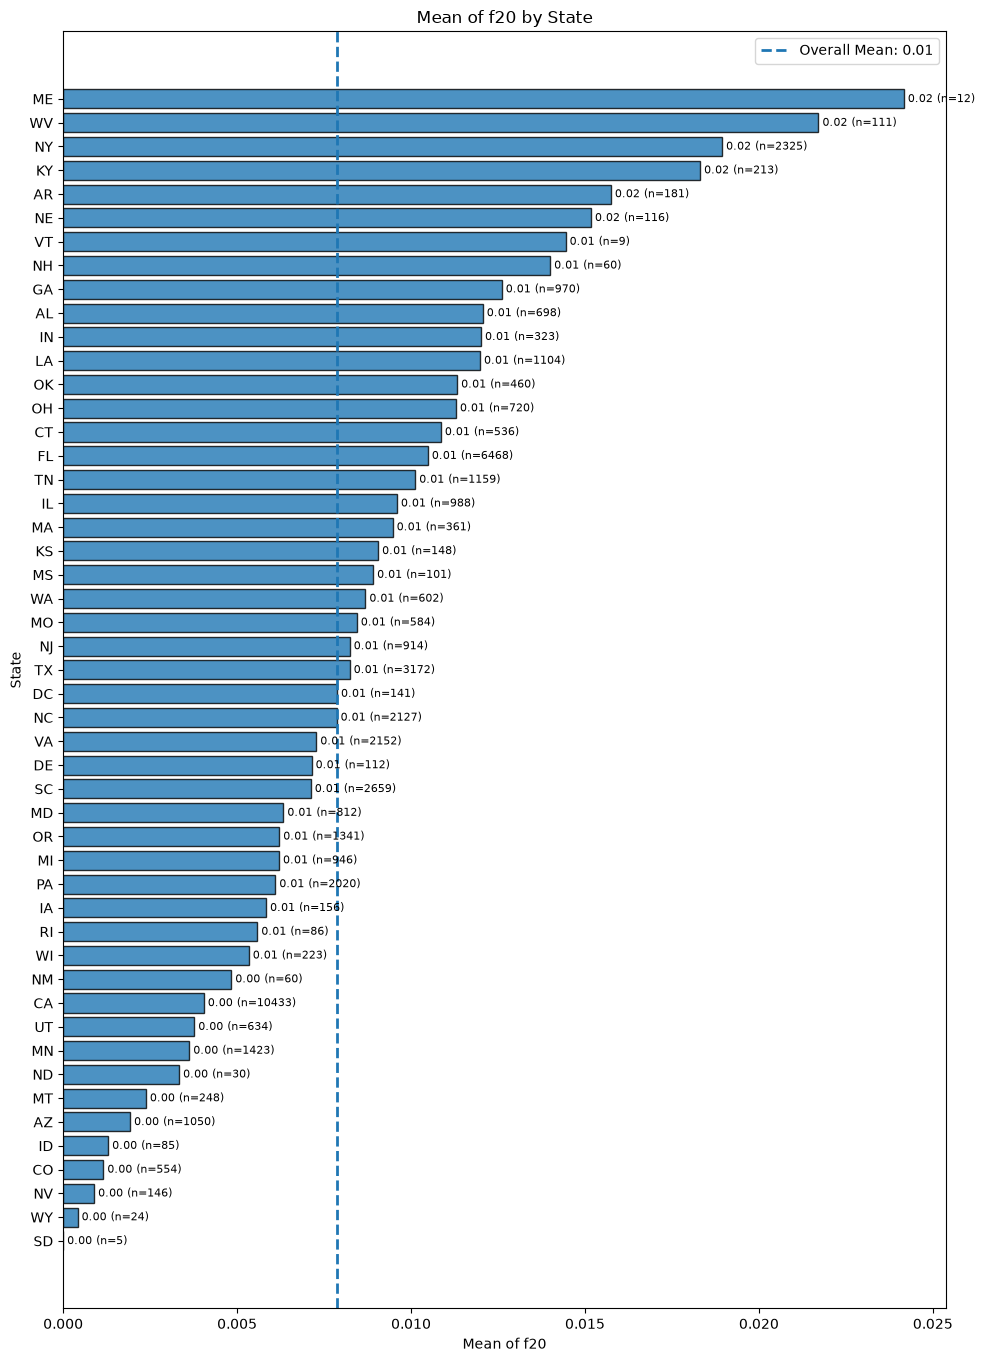

In [14]:
plot_state_feature_means(
    ["f16", "f17", "f19", "f20"]
)

For the missing values in environmental features (`f16`, `f17`, `f19`, and `f20`), we observed that these values are highly dependent on the accident location, especially the city and state.

Therefore, filling the missing values using only the global mean/mode does not make sense, as it ignores local environmental patterns and may introduce bias into the data.

In [15]:
# Features to impute
environmental_features = ["f16", "f17", "f19", "f20"]

# Smoothing parameters
alpha_city = 20
alpha_state = 100

# Store train-based imputation statistics
hierarchical_imputation_stats = {}


def fit_hierarchical_imputer(
    train_data,
    feature,
    city_col="City",
    state_col="State",
    alpha_city=20,
    alpha_state=100
):
    # Use only valid training values
    valid_data = train_data[
        [state_col, city_col, feature]
    ].dropna(subset=[feature]).copy()

    # Calculate the global mean
    global_mean = valid_data[feature].mean()

    if pd.isna(global_mean):
        raise ValueError(
            f"Feature '{feature}' has no valid values in train_df."
        )

    # Calculate state statistics
    state_stats = (
        valid_data
        .dropna(subset=[state_col])
        .groupby(state_col)[feature]
        .agg(["mean", "count"])
        .reset_index()
    )

    # Smooth state means toward the global mean
    state_stats["smoothed_mean"] = (
        state_stats["count"] * state_stats["mean"]
        + alpha_state * global_mean
    ) / (
        state_stats["count"] + alpha_state
    )

    state_lookup = dict(
        zip(
            state_stats[state_col],
            state_stats["smoothed_mean"]
        )
    )

    # Calculate city statistics
    city_stats = (
        valid_data
        .dropna(subset=[state_col, city_col])
        .groupby([state_col, city_col])[feature]
        .agg(["mean", "count"])
        .reset_index()
    )

    # Add the smoothed state mean for each city
    city_stats["state_smoothed_mean"] = (
        city_stats[state_col].map(state_lookup)
    )

    # Smooth city means toward the state mean
    city_stats["smoothed_mean"] = (
        city_stats["count"] * city_stats["mean"]
        + alpha_city * city_stats["state_smoothed_mean"]
    ) / (
        city_stats["count"] + alpha_city
    )

    city_lookup = {
        (state, city): smoothed_mean
        for state, city, smoothed_mean in zip(
            city_stats[state_col],
            city_stats[city_col],
            city_stats["smoothed_mean"]
        )
    }

    return {
        "global_mean": global_mean,
        "state_lookup": state_lookup,
        "city_lookup": city_lookup,
        "state_stats": state_stats,
        "city_stats": city_stats
    }


def apply_hierarchical_imputer(
    data,
    feature,
    imputation_stats,
    city_col="City",
    state_col="State"
):
    # Create city-state keys
    city_keys = pd.Series(
        list(zip(data[state_col], data[city_col])),
        index=data.index
    )

    # Get city-based estimates
    city_estimates = city_keys.map(
        imputation_stats["city_lookup"]
    )

    # Get state-based estimates
    state_estimates = data[state_col].map(
        imputation_stats["state_lookup"]
    )

    # City -> state -> global fallback
    final_estimates = (
        city_estimates
        .fillna(state_estimates)
        .fillna(imputation_stats["global_mean"])
    )

    # Fill only missing values
    data[feature] = data[feature].fillna(final_estimates)


# Convert environmental features to numeric
for dataset in [train_df, validation_df, test_df]:
    for feature in environmental_features:
        dataset[feature] = pd.to_numeric(
            dataset[feature],
            errors="coerce"
        )

# Show missing values before imputation
print("Missing values before imputation:")
display(
    pd.DataFrame({
        "Train": train_df[environmental_features].isna().sum(),
        "Validation": validation_df[environmental_features].isna().sum(),
        "Test": test_df[environmental_features].isna().sum()
    })
)

# Fit on train and apply to all datasets
for feature in environmental_features:
    hierarchical_imputation_stats[feature] = (
        fit_hierarchical_imputer(
            train_data=train_df,
            feature=feature,
            alpha_city=alpha_city,
            alpha_state=alpha_state
        )
    )

    for dataset in [train_df, validation_df, test_df]:
        apply_hierarchical_imputer(
            data=dataset,
            feature=feature,
            imputation_stats=hierarchical_imputation_stats[feature]
        )

# Show missing values after imputation
print("Missing values after imputation:")
display(
    pd.DataFrame({
        "Train": train_df[environmental_features].isna().sum(),
        "Validation": validation_df[environmental_features].isna().sum(),
        "Test": test_df[environmental_features].isna().sum()
    })
)

# Show global means learned from train
global_means = pd.Series({
    feature: hierarchical_imputation_stats[feature]["global_mean"]
    for feature in environmental_features
}, name="Train Global Mean")

print("Global means learned from train_df:")
display(global_means.to_frame())

Missing values before imputation:


,Train,Validation,Test
f16,1531,326,351
f17,1263,244,305
f19,5252,1094,1152
f20,20198,4255,4353


Missing values after imputation:


,Train,Validation,Test
f16,0,0,0
f17,0,0,0
f19,0,0,0
f20,0,0,0


Global means learned from train_df:


,Train Global Mean
f16,64.655771
f17,29.540571
f19,7.666521
f20,0.007886


##### Handling Missing Numerical Environmental Features

The missing values in `f16`, `f17`, `f19`, and `f20` were not filled using a single global mean or mode because these features represent environmental conditions, which can vary depending on the accident location.

Instead, we used **Hierarchical Shrinkage Imputation**, where the missing values are estimated using information from the city, state, and the entire training dataset.

The idea is that:
- If a city has enough valid samples, its local statistics should have more influence.
- If a city has limited data, the estimation should rely more on the state and global patterns to avoid unreliable values.

First, the state-level value is adjusted using the global mean:

$$
\tilde{\mu}_s =
\frac{n_s\mu_s + \alpha_s\mu_g}
{n_s + \alpha_s}
$$

Then, the city-level value is adjusted using the smoothed state value:

$$
\tilde{\mu}_c =
\frac{n_c\mu_c + \alpha_c\tilde{\mu}_s}
{n_c + \alpha_c}
$$

The final imputed value can be represented as a weighted combination of city, state, and global statistics:

$$
\hat{x} =
w_c\mu_c + w_s\mu_s + w_g\mu_g
$$

where the weights are calculated as:

$$
w_c = \frac{n_c}{n_c+\alpha_c}
$$

$$
w_s =
\frac{\alpha_c}{n_c+\alpha_c}
\times
\frac{n_s}{n_s+\alpha_s}
$$

$$
w_g =
\frac{\alpha_c}{n_c+\alpha_c}
\times
\frac{\alpha_s}{n_s+\alpha_s}
$$

and:

$$
w_c + w_s + w_g = 1
$$

In these formulas:

- $n_c$: number of available (non-missing) values for the feature in the city
- $n_s$: number of available (non-missing) values for the feature in the state
- $\mu_c$: city-level mean/mode
- $\mu_s$: state-level mean/mode
- $\mu_g$: global mean/mode from the training dataset
- $\alpha_c$ and $\alpha_s$: smoothing parameters that control how much data is needed before trusting city/state statistics

With this method, locations with enough data rely more on their own local patterns, while locations with fewer samples are gradually shifted toward more reliable state and global information.

### Decision About `Wind_Drection` :

Normalizing its values (and putting 'unknown' instead of null-values)

In [16]:
def normalize_wind_direction(value):
    
    if pd.isna(value):
        return "Unknown"
    
    value = str(value).strip().upper()
    
    mapping = {
        "N": "N",
        "NORTH": "N",
        
        "S": "S",
        "SOUTH": "S",
        
        "E": "E",
        "EAST": "E",
        
        "W": "W",
        "WEST": "W",
        
        "NE": "NE",
        "NORTH EAST": "NE",
        "NORTHEAST": "NE",
        
        "NW": "NW",
        "NORTH WEST": "NW",
        "NORTHWEST": "NW",
        
        "SE": "SE",
        "SOUTH EAST": "SE",
        "SOUTHEAST": "SE",
        
        "SW": "SW",
        "SOUTH WEST": "SW",
        "SOUTHWEST": "SW",
        
        "ENE": "ENE",
        "EAST NORTHEAST": "ENE",
        
        "ESE": "ESE",
        "EAST SOUTHEAST": "ESE",
        
        "NNE": "NNE",
        "NORTH NORTHEAST": "NNE",
        
        "NNW": "NNW",
        "NORTH NORTHWEST": "NNW",
        
        "SSE": "SSE",
        "SOUTH SOUTHEAST": "SSE",
        
        "SSW": "SSW",
        "SOUTH SOUTHWEST": "SSW",
        
        "WSW": "WSW",
        "WEST SOUTHWEST": "WSW",
        
        "WNW": "WNW",
        "WEST NORTHWEST": "WNW",
        
        "VAR": "VARIABLE",
        "VARIABLE": "VARIABLE",
        "VRB": "VARIABLE",
        
        "CALM": "CALM"
    }
    
    return mapping.get(value, value)


print("\n" + "=" * 80)
print("Wind_Direction Column before normalization:")
display(train_df["Wind_Direction"].value_counts(dropna=False).head(30))

train_df["Wind_Direction"] = train_df["Wind_Direction"].apply(normalize_wind_direction)
validation_df["Wind_Direction"] = validation_df["Wind_Direction"].apply(normalize_wind_direction)
test_df["Wind_Direction"] = test_df["Wind_Direction"].apply(normalize_wind_direction)

print("Wind_Direction column after normalization:")
display(train_df["Wind_Direction"].value_counts(dropna=False).head(30))

print("Wind_Direction missing column count in train after normalization:", train_df["Wind_Direction"].isna().sum())
print("Wind_Direction missing column count in validation after normalization:", validation_df["Wind_Direction"].isna().sum())
print("Wind_Direction missing column count in test after normalization:", test_df["Wind_Direction"].isna().sum())



Wind_Direction Column before normalization:


Wind_Direction
CALM        8706
S           3687
SSW         3532
WNW         3427
W           3416
Calm        3399
NW          3312
SW          3291
WSW         3218
SSE         3203
NNW         3049
N           2789
SE          2601
ESE         2515
E           2495
NE          2452
ENE         2335
NNE         2326
VAR         2183
South       1592
NaN         1576
West        1477
North       1419
Variable    1079
East         921
Name: count, dtype: int64

Wind_Direction column after normalization:


Wind_Direction
CALM        12105
S            5279
W            4893
N            4208
SSW          3532
WNW          3427
E            3416
NW           3312
SW           3291
VARIABLE     3262
WSW          3218
SSE          3203
NNW          3049
SE           2601
ESE          2515
NE           2452
ENE          2335
NNE          2326
Unknown      1576
Name: count, dtype: int64

Wind_Direction missing column count in train after normalization: 0
Wind_Direction missing column count in validation after normalization: 0
Wind_Direction missing column count in test after normalization: 0


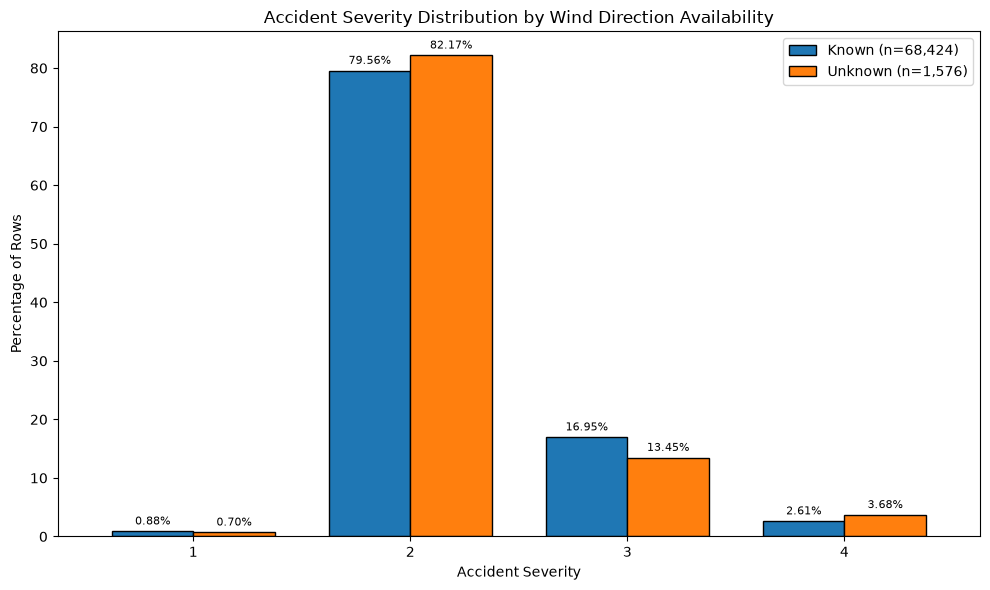

In [17]:
# Prepare wind direction data
wind_unknown_df = train_df[["Wind_Direction", "y"]].copy()

# Normalize text values
wind_unknown_df["Wind_Direction"] = (
    wind_unknown_df["Wind_Direction"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Convert target to numeric
wind_unknown_df["y"] = pd.to_numeric(
    wind_unknown_df["y"],
    errors="coerce"
)

# Define wind direction status
wind_unknown_df["Wind_Direction_Status"] = (
    wind_unknown_df["Wind_Direction"]
    .eq("UNKNOWN")
    .map({
        True: "Unknown",
        False: "Known"
    })
)

# Remove rows with missing target
wind_unknown_df = wind_unknown_df.dropna(subset=["y"])

# Calculate target percentages
wind_percentage_table = pd.crosstab(
    wind_unknown_df["y"],
    wind_unknown_df["Wind_Direction_Status"],
    normalize="columns"
).mul(100)

wind_percentage_table = wind_percentage_table.reindex(
    index=[1, 2, 3, 4],
    columns=["Known", "Unknown"],
    fill_value=0
)

# Count rows in each group
wind_group_counts = (
    wind_unknown_df["Wind_Direction_Status"]
    .value_counts()
)

# Plot target distributions
ax = wind_percentage_table.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black",
    width=0.75
)

plt.title("Accident Severity Distribution by Wind Direction Availability")
plt.xlabel("Accident Severity")
plt.ylabel("Percentage of Rows")
plt.xticks(rotation=0)

ax.legend([
    f"Known (n={wind_group_counts.get('Known', 0):,})",
    f"Unknown (n={wind_group_counts.get('Unknown', 0):,})"
])

# Show percentages above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [18]:
# Prepare required columns
wind_chi_df = train_df[["Wind_Direction", "y"]].copy()

# Normalize text values
wind_chi_df["Wind_Direction"] = (
    wind_chi_df["Wind_Direction"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Convert target to numeric
wind_chi_df["y"] = pd.to_numeric(
    wind_chi_df["y"],
    errors="coerce"
)

# Define wind direction status
wind_chi_df["Wind_Direction_Status"] = (
    wind_chi_df["Wind_Direction"]
    .eq("UNKNOWN")
    .map({
        True: "Unknown",
        False: "Known"
    })
)

# Remove rows with missing target
wind_chi_df = wind_chi_df.dropna(subset=["y"])

# Create the contingency table
wind_contingency_table = pd.crosstab(
    wind_chi_df["Wind_Direction_Status"],
    wind_chi_df["y"]
).reindex(
    index=["Known", "Unknown"],
    columns=[1, 2, 3, 4],
    fill_value=0
)

print("Contingency table:")
display(wind_contingency_table)

# Calculate row percentages
wind_percentage_table = wind_contingency_table.div(
    wind_contingency_table.sum(axis=1),
    axis=0
).mul(100).round(2)

print("Target distribution percentages:")
display(wind_percentage_table)

# Run the Chi-Square test
chi2_stat, p_value, degrees_of_freedom, expected_counts = (
    chi2_contingency(wind_contingency_table)
)

wind_expected_table = pd.DataFrame(
    expected_counts,
    index=wind_contingency_table.index,
    columns=wind_contingency_table.columns
)

print(f"Chi-Square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {p_value:.6f}")

print("\nExpected counts:")
display(wind_expected_table.round(2))

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print(
        "Result: Reject H0. "
        "Unknown wind direction and accident severity are associated."
    )
else:
    print(
        "Result: Fail to reject H0. "
        "There is not enough evidence of an association."
    )

# Check the Chi-Square assumption
if (wind_expected_table < 5).any().any():
    print(
        "Warning: Some expected counts are below 5. "
        "The Chi-Square result may be unreliable."
    )

Contingency table:


y,1,2,3,4
Wind_Direction_Status,,,,
Known,603,54439,11598,1784
Unknown,11,1295,212,58


Target distribution percentages:


y,1,2,3,4
Wind_Direction_Status,,,,
Known,0.88,79.56,16.95,2.61
Unknown,0.70,82.17,13.45,3.68


Chi-Square statistic: 19.8215
Degrees of freedom: 3
P-value: 0.000185

Expected counts:


y,1,2,3,4
Wind_Direction_Status,,,,
Known,600.18,54479.19,11544.11,1800.53
Unknown,13.82,1254.81,265.89,41.47


Result: Reject H0. Unknown wind direction and accident severity are associated.


In [19]:
# Calculate Cramer's V
n = wind_contingency_table.to_numpy().sum()
rows, columns = wind_contingency_table.shape

min_dimension = min(rows - 1, columns - 1)

if n == 0 or min_dimension == 0:
    raise ValueError("Cramer's V cannot be calculated from this table.")

cramers_v = (
    chi2_stat / (n * min_dimension)
) ** 0.5

print(f"Sample size: {n:,}")
print(f"Cramer's V: {cramers_v:.4f}")

# Interpret the association strength
if cramers_v < 0.10:
    strength = "Negligible"
elif cramers_v < 0.30:
    strength = "Weak"
elif cramers_v < 0.50:
    strength = "Moderate"
else:
    strength = "Strong"

print(f"Association strength: {strength}")

Sample size: 70,000
Cramer's V: 0.0168
Association strength: Negligible


Although the Chi-Squared test suggested a relationship between `is_wind_unknown` and the target variable, the very small Cramér’s V indicated that this relationship was weak.

Since only about 2% of the wind-direction values were `Unknown`, we decided not to create this additional feature. Instead, these values will be treated as missing and filled later using more reliable estimation methods.

In [20]:
# Create wind status indicators
for dataset in [train_df, validation_df, test_df]:
    wind_values = (
        dataset["Wind_Direction"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    dataset["Wind_D_Calm"] = (
        wind_values.eq("CALM")
    ).astype("int8")

    dataset["Wind_D_Variable"] = (
        wind_values.eq("VARIABLE")
    ).astype("int8")

# Check train results
display(
    pd.crosstab(
        train_df["Wind_Direction"],
        [
            train_df["Wind_D_Calm"],
            train_df["Wind_D_Variable"]
        ]
    )
)

Wind_D_Calm         0            1
Wind_D_Variable     0     1      0
Wind_Direction                    
CALM                0     0  12105
E                3416     0      0
ENE              2335     0      0
ESE              2515     0      0
N                4208     0      0
NE               2452     0      0
NNE              2326     0      0
NNW              3049     0      0
NW               3312     0      0
S                5279     0      0
SE               2601     0      0
SSE              3203     0      0
SSW              3532     0      0
SW               3291     0      0
Unknown          1576     0      0
VARIABLE            0  3262      0
W                4893     0      0
WNW              3427     0      0
WSW              3218     0      0

In [21]:
# Define direction angles
wind_angle_degrees = {
    "E": 0.0,
    "ENE": 22.5,
    "NE": 45.0,
    "NNE": 67.5,
    "N": 90.0,
    "NNW": 112.5,
    "NW": 135.0,
    "WNW": 157.5,
    "W": 180.0,
    "WSW": 202.5,
    "SW": 225.0,
    "SSW": 247.5,
    "S": 270.0,
    "SSE": 292.5,
    "SE": 315.0,
    "ESE": 337.5
}

valid_wind_values = set(wind_angle_degrees) | {
    "CALM",
    "VARIABLE",
    "UNKNOWN"
}

for dataset in [train_df, validation_df, test_df]:
    wind_values = (
        dataset["Wind_Direction"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    # Check unexpected values
    unexpected_values = sorted(
        set(wind_values.dropna()) - valid_wind_values
    )

    if unexpected_values:
        raise ValueError(
            f"Unexpected wind directions: {unexpected_values}"
        )

    # Map directions to angles
    wind_angles = wind_values.map(wind_angle_degrees)
    wind_radians = np.deg2rad(wind_angles)

    dataset["Wind_D_Sin"] = np.sin(wind_radians)
    dataset["Wind_D_Cos"] = np.cos(wind_radians)

    # Set non-directional values to zero
    special_mask = wind_values.isin([
        "CALM",
        "VARIABLE"
    ])

    dataset.loc[
        special_mask,
        ["Wind_D_Sin", "Wind_D_Cos"]
    ] = 0.0

    # Keep unknown values missing
    unknown_mask = wind_values.eq("UNKNOWN")

    dataset.loc[
        unknown_mask,
        ["Wind_D_Sin", "Wind_D_Cos"]
    ] = np.nan

# Check train encoding
display(
    train_df[
        [
            "Wind_Direction",
            "Wind_D_Calm",
            "Wind_D_Variable",
            "Wind_D_Sin",
            "Wind_D_Cos"
        ]
    ].drop_duplicates().sort_values("Wind_Direction")
)

,Wind_Direction,Wind_D_Calm,Wind_D_Variable,Wind_D_Sin,Wind_D_Cos
12,CALM,1,0,0.000000e+00,0.000000e+00
97,E,0,0,0.000000e+00,1.000000e+00
75,ENE,0,0,3.826834e-01,9.238795e-01
4,ESE,0,0,-3.826834e-01,9.238795e-01
7,N,0,0,1.000000e+00,6.123234e-17
73,NE,0,0,7.071068e-01,7.071068e-01
0,NNE,0,0,9.238795e-01,3.826834e-01
25,NNW,0,0,9.238795e-01,-3.826834e-01
8,NW,0,0,7.071068e-01,-7.071068e-01
38,S,0,0,-1.000000e+00,-1.836970e-16


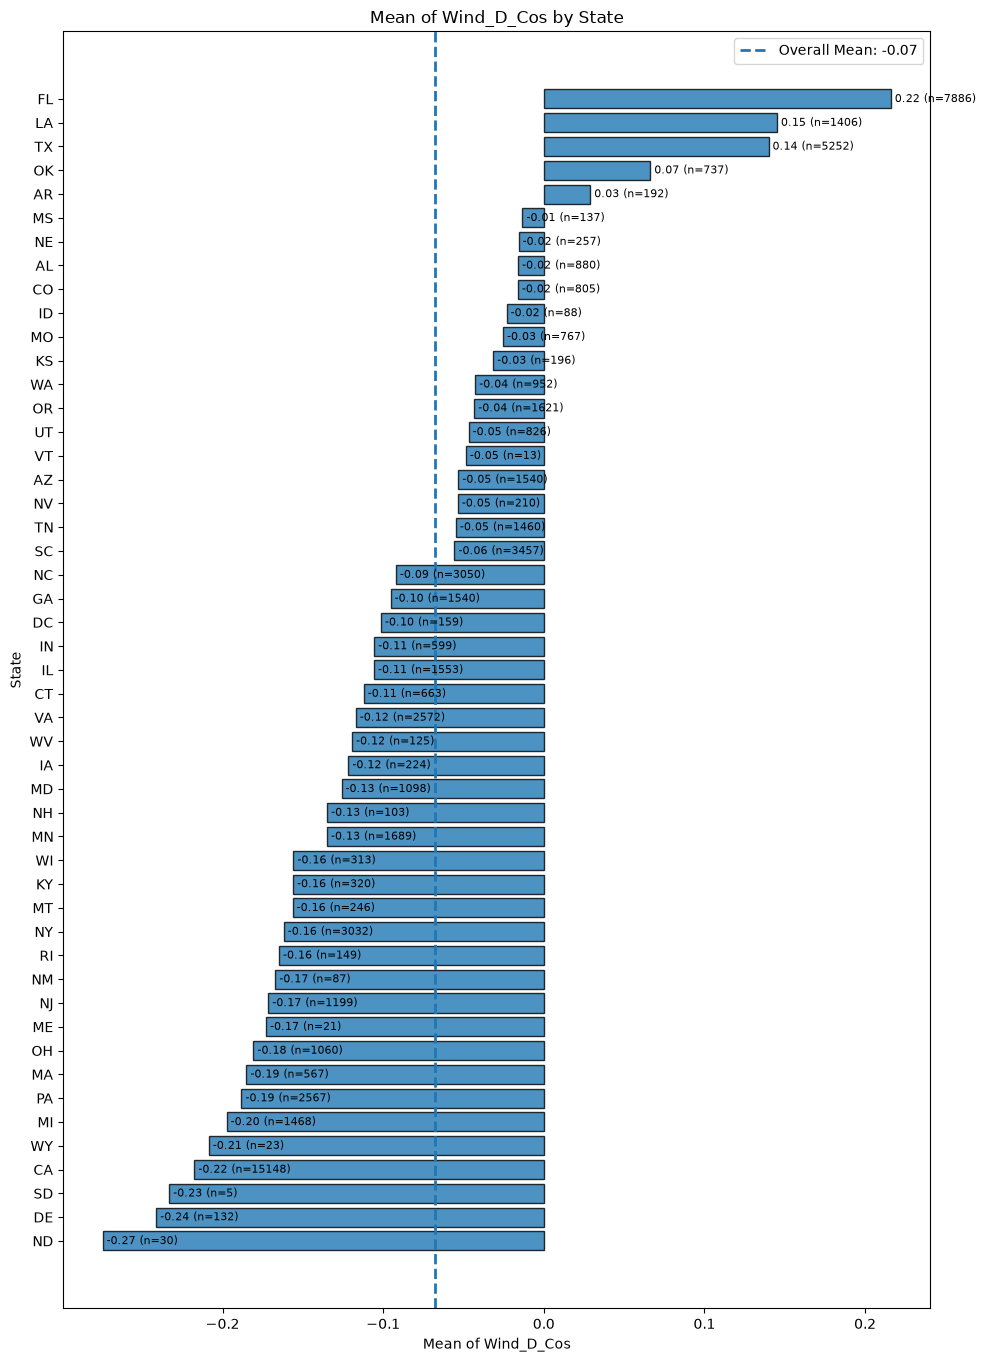

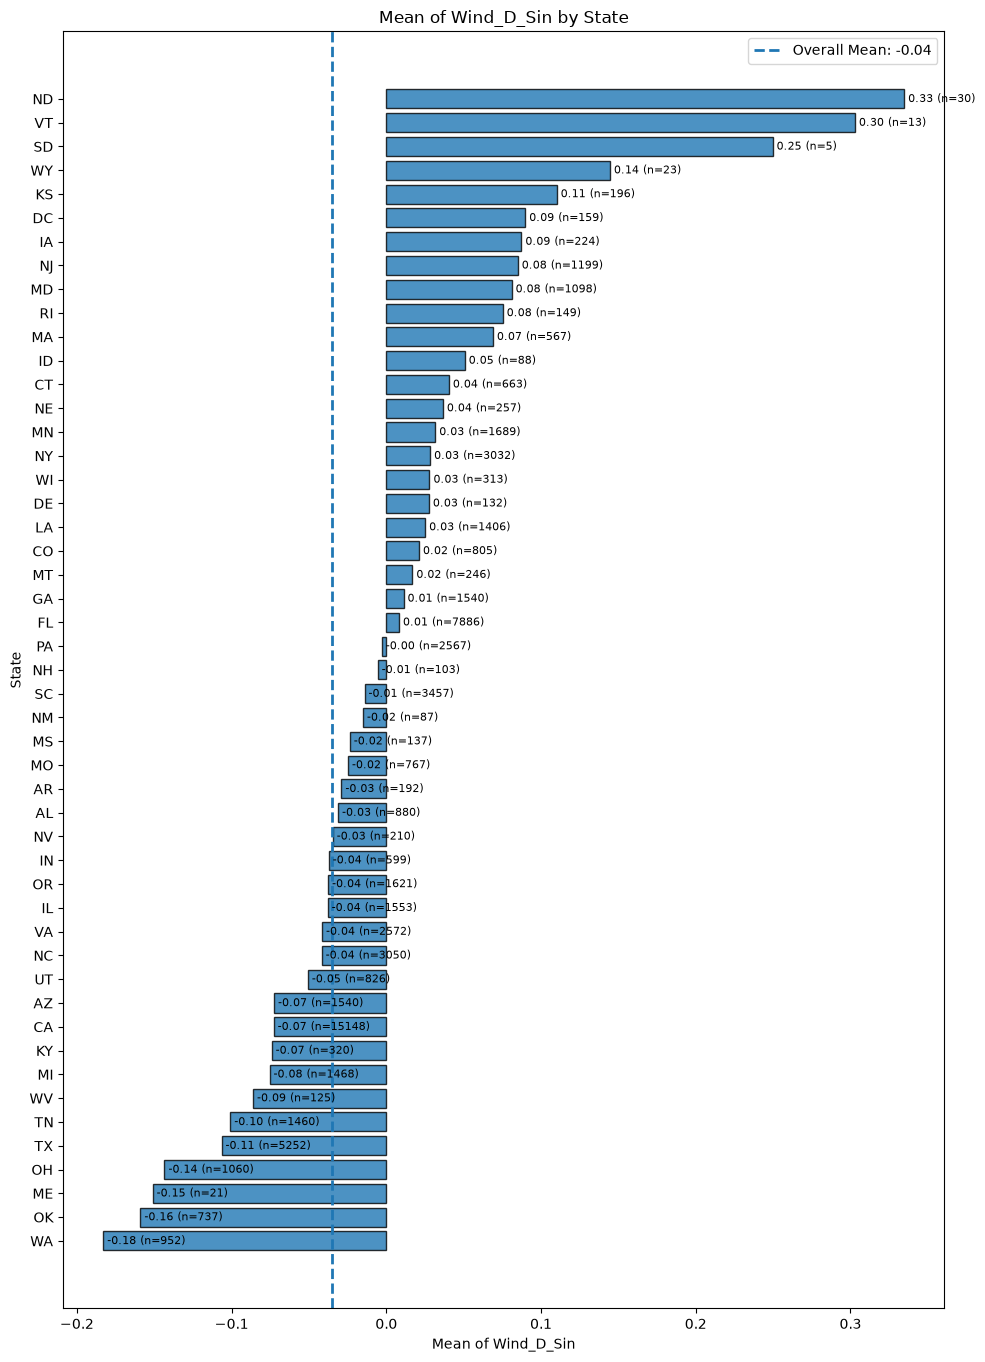

In [22]:
plot_state_feature_means(
    ['Wind_D_Cos' , 'Wind_D_Sin']
)

In [23]:
# Define wind components
wind_components = [
    "Wind_D_Sin",
    "Wind_D_Cos"
]

# Use only real directions for fitting
train_wind_values = (
    train_df["Wind_Direction"]
    .astype("string")
    .str.strip()
    .str.upper()
)

valid_direction_mask = train_wind_values.isin(
    list(wind_angle_degrees)
)

wind_fit_df = train_df.loc[
    valid_direction_mask
].copy()

# Store train-based statistics
wind_direction_imputation_stats = {}

# Fit on train and apply to all datasets
for component in wind_components:
    wind_direction_imputation_stats[component] = (
        fit_hierarchical_imputer(
            train_data=wind_fit_df,
            feature=component,
            alpha_city=alpha_city,
            alpha_state=alpha_state
        )
    )

    for dataset in [
        train_df,
        validation_df,
        test_df
    ]:
        apply_hierarchical_imputer(
            data=dataset,
            feature=component,
            imputation_stats=(
                wind_direction_imputation_stats[component]
            )
        )

# Reduce memory usage
for dataset in [
    train_df,
    validation_df,
    test_df
]:
    dataset[wind_components] = dataset[
        wind_components
    ].astype("float32")

# Check remaining missing values
print("Missing values after wind imputation:")

display(
    pd.DataFrame({
        "Train": train_df[wind_components].isna().sum(),
        "Validation": validation_df[wind_components].isna().sum(),
        "Test": test_df[wind_components].isna().sum()
    })
)

# Show imputed unknown rows
unknown_train_mask = (
    train_df["Wind_Direction"]
    .astype("string")
    .str.strip()
    .str.upper()
    .eq("UNKNOWN")
)

display(
    train_df.loc[
        unknown_train_mask,
        [
            "State",
            "City",
            "Wind_Direction",
            "Wind_D_Sin",
            "Wind_D_Cos"
        ]
    ].head(10)
)

Missing values after wind imputation:


,Train,Validation,Test
Wind_D_Sin,0,0,0
Wind_D_Cos,0,0,0


,State,City,Wind_Direction,Wind_D_Sin,Wind_D_Cos
3,OR,North Bayside,Unknown,-0.051418,-0.061855
36,VA,Chesterfield,Unknown,-0.106995,-0.207867
72,VA,Hampton,Unknown,0.093261,-0.124120
95,CA,Gardena,Unknown,-0.196084,-0.368145
98,SC,Lancaster,Unknown,0.026684,-0.265829
112,SC,Prosperity,Unknown,-0.066480,-0.128859
135,CA,Altadena,Unknown,-0.105984,-0.316136
143,TX,Fort Worth,Unknown,-0.095475,0.079158
267,CA,Corte Madera,Unknown,-0.197126,-0.274901
284,NC,Chapel Hill,Unknown,-0.056683,-0.124380


In [24]:
# Drop the original wind direction column
for dataset in [train_df, validation_df, test_df]:
    dataset.drop(
        columns=["Wind_Direction"],
        inplace=True,
        errors="ignore"
    )

##### Handling Wind_Direction Feature

Since `Wind_Direction` is a cyclical feature, we avoided Label Encoding because it would not preserve the real similarity between nearby directions such as `N`, `NNE`, and `NNW`.

Instead, we converted this feature into four new columns:

- `Wind_D_Calm`
- `Wind_D_Variable`
- `Wind_D_Sin`
- `Wind_D_Cos`

`CALM` and `VARIABLE` were represented using separate binary columns because they do not describe a fixed direction.

For valid wind directions, we assigned an angle and used sine and cosine values:

$$
Wind\_D\_Sin = \sin(\theta)
$$

$$
Wind\_D\_Cos = \cos(\theta)
$$

This cyclical encoding preserves the closeness between neighboring directions while using fewer features than One-Hot Encoding.

The `Unknown` values were initially kept as missing in `Wind_D_Sin` and `Wind_D_Cos`. They were later estimated using the same hierarchical city-state-global approach used for the environmental features, since wind direction also depends on geographical location.

After creating the new features, the original `Wind_Direction` column was removed. No additional scaling was required because sine and cosine values are already limited to the range `[-1, 1]`.

### Decision About `Weather_Time` :

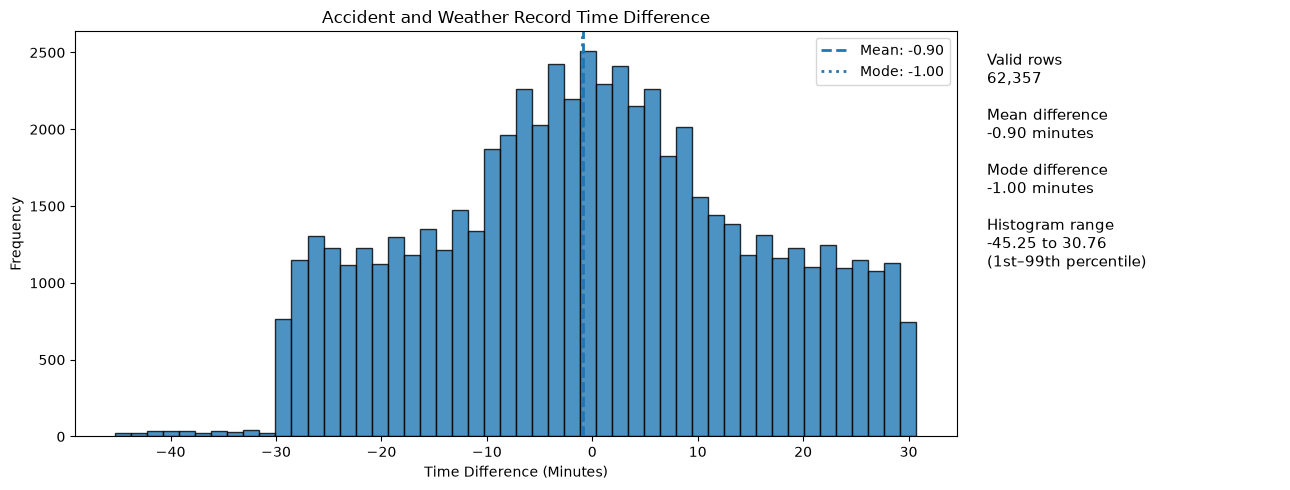

In [25]:
# Prepare time columns from train data
time_df = train_df[
    ["Accident_Time", "Weather_Time"]
].copy()

# Convert columns to datetime
time_df["Accident_Time"] = pd.to_datetime(
    time_df["Accident_Time"],
    errors="coerce"
)

time_df["Weather_Time"] = pd.to_datetime(
    time_df["Weather_Time"],
    errors="coerce"
)

# Calculate time difference in minutes
time_difference = (
    time_df["Accident_Time"] - time_df["Weather_Time"]
).dt.total_seconds() / 60

# Remove missing and infinite values
time_difference = (
    time_difference
    .replace([float("inf"), float("-inf")], pd.NA)
    .dropna()
)

# Calculate statistics on all valid values
mean_delay = time_difference.mean()

mode_values = time_difference.mode()
mode_delay = (
    mode_values.iloc[0]
    if not mode_values.empty
    else float("nan")
)

# Use percentiles only for histogram zoom
lower_limit = time_difference.quantile(0.01)
upper_limit = time_difference.quantile(0.99)

zoomed_difference = time_difference[
    time_difference.between(
        lower_limit,
        upper_limit
    )
]

# Create histogram and statistics panel
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [4, 1.4]}
)

axes[0].hist(
    zoomed_difference,
    bins=50,
    edgecolor="black",
    alpha=0.8
)

axes[0].axvline(
    mean_delay,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_delay:.2f}"
)

axes[0].axvline(
    mode_delay,
    linestyle=":",
    linewidth=2,
    label=f"Mode: {mode_delay:.2f}"
)

axes[0].set_title(
    "Accident and Weather Record Time Difference"
)
axes[0].set_xlabel("Time Difference (Minutes)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Show statistics beside the histogram
axes[1].axis("off")

statistics_text = (
    f"Valid rows\n"
    f"{len(time_difference):,}\n\n"
    f"Mean difference\n"
    f"{mean_delay:.2f} minutes\n\n"
    f"Mode difference\n"
    f"{mode_delay:.2f} minutes\n\n"
    f"Histogram range\n"
    f"{lower_limit:.2f} to {upper_limit:.2f}\n"
    f"(1st–99th percentile)"
)

axes[1].text(
    0.05,
    0.95,
    statistics_text,
    va="top",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [26]:
# Count rows where both time columns are missing
display(
    pd.Series({
        "Train": (
            train_df["Accident_Time"].isna()
            & train_df["Weather_Time"].isna()
        ).sum(),

        "Validation": (
            validation_df["Accident_Time"].isna()
            & validation_df["Weather_Time"].isna()
        ).sum(),

        "Test": (
            test_df["Accident_Time"].isna()
            & test_df["Weather_Time"].isna()
        ).sum()
    }, name="Both Times Missing")
)

Train         0
Validation    0
Test          0
Name: Both Times Missing, dtype: int64

In [27]:
display(
    pd.DataFrame({
        "Train": train_df.isna().sum(),
        "Validation": validation_df.isna().sum(),
        "Test": test_df.isna().sum()
    })
)

,Train,Validation,Test
Source,0,0,0
Accident_Time,0,0,0
Additional_Lng,0,0,0
f6,0,0,0
Description,0,0,0
Street,93,22,25
City,2,0,0
County,0,0,0
State,0,0,0
Zipcode,22,6,2


`Accident_Time` and `Weather_Time` are too close to each other!

In [28]:
for dataset in [
    train_df,
    validation_df,
    test_df
]:

    dataset["Accident_Time"] = pd.to_datetime(
    dataset["Accident_Time"],
    format="mixed",
    errors="coerce"
    ).dt.floor("s") #some of the values in Accident_Time were like : 2022-07-04 14:05:00.000000000

    dataset["Weather_Time"] = pd.to_datetime(
        dataset["Weather_Time"],
        errors="coerce"
    )

    # Calculate delay in minutes
    dataset["Record_Delay_Time"] = (
        dataset["Accident_Time"]
        - dataset["Weather_Time"]
    ).dt.total_seconds() / 60

    # Replace missing delay values with mean_delay
    dataset["Record_Delay_Time"] = (
        dataset["Record_Delay_Time"]
        .replace(
            [float("inf"), float("-inf")],
            pd.NA
        )
        .fillna(mean_delay)
        .astype("float32")
    )

    # Remove the original weather time
    dataset.drop(
        columns=["Weather_Time"],
        inplace=True
    )

# Check the result
display(
    pd.DataFrame({
        "Train Missing": [
            train_df["Record_Delay_Time"].isna().sum()
        ],
        "Validation Missing": [
            validation_df["Record_Delay_Time"].isna().sum()
        ],
        "Test Missing": [
            test_df["Record_Delay_Time"].isna().sum()
        ]
    })
)

display(
    train_df[
        ["Accident_Time", "Record_Delay_Time"]
    ].head()
)

,Train Missing,Validation Missing,Test Missing
0,0,0,0


,Accident_Time,Record_Delay_Time
0,2020-12-02 17:01:14,10.233334
1,2021-06-03 16:32:42,10.700000
2,2019-11-04 17:28:00,-17.000000
3,2019-02-24 03:04:55,-0.899540
4,2021-12-01 18:16:32,23.533333


We first confirmed that `Accident_Time` and `Weather_Time` were usually very close to each other in minutes.

Since keeping both timestamps would provide mostly redundant information, we removed `Weather_Time` and created a new feature called `Record_Delay_Time`, representing the time difference between the weather record and the accident:

$$
Record\_Delay\_Time = Weather\_Time - Accident\_Time
$$

The missing values in `Record_Delay_Time` were filled using the mean delay calculated from the training data.

### Decision About `Airport_Code` , `ZipCode` and `Street` :

We removed `Zipcode` and `Airport_Code` because they were not suitable for predicting accident severity. Even if they contained useful information, encoding their large number of unique values would require too many additional features.

Their missing values were therefore not imputed. Other columns such as `Street`, `City`, and `Additional_Lng` can still provide location-related information when needed.

Since only a very small number of rows had missing values in `Street`, we removed those rows instead of estimating the street names.

In [29]:
# Store datasets for processing
datasets = {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}

# Support possible column name variations
columns_to_drop = [
    "ZipCode",
    "Zipcode",
    "Airport_Code",
    "Airpot_Code"
]

removal_summary = []

for dataset_name, dataset in datasets.items():
    if "Street" not in dataset.columns:
        raise ValueError(
            f"'Street' column does not exist in {dataset_name}."
        )

    rows_before = len(dataset)
    missing_street_count = dataset["Street"].isna().sum()

    # Drop unnecessary columns
    existing_columns = [
        column for column in columns_to_drop
        if column in dataset.columns
    ]

    dataset.drop(
        columns=existing_columns,
        inplace=True
    )

    # Drop rows with missing Street
    dataset.dropna(
        subset=["Street"],
        inplace=True
    )

    dataset.reset_index(
        drop=True,
        inplace=True
    )

    removal_summary.append({
        "Dataset": dataset_name,
        "Rows Before": rows_before,
        "Missing Street Rows": missing_street_count,
        "Rows After": len(dataset)
    })

# Show removed and remaining row counts
removal_summary = pd.DataFrame(removal_summary)

display(removal_summary)

,Dataset,Rows Before,Missing Street Rows,Rows After
0,Train,70000,93,69907
1,Validation,15000,22,14978
2,Test,15000,25,14975


### Decision About `f32` , `f33` and `f34` :

We first examined the value distributions of `f32`, `f33`, and `f34` using bar charts.

These columns were then renamed to `D1`, `D2`, and `D3`. Since they only indicated whether the accident occurred during the day or night, their categorical values were converted into binary values:

- `Day` → `1`
- `Night` → `0`

Finally, the missing values in each column were filled using the mode of that column, calculated only from the training data.

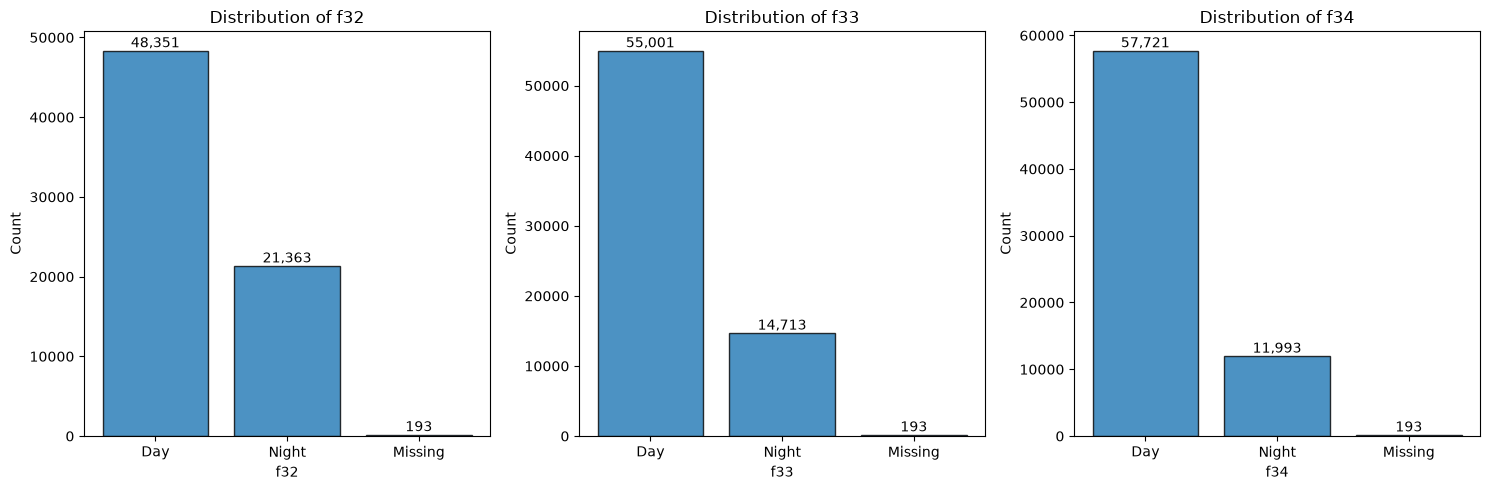

Modes learned from train:
{'D1': 1, 'D2': 1, 'D3': 1}


,Train Missing,Validation Missing,Test Missing
D1,0,0,0
D2,0,0,0
D3,0,0,0


In [30]:
# Original and new column names
day_night_columns = ["f32", "f33", "f34"]

rename_map = {
    "f32": "D1",
    "f33": "D2",
    "f34": "D3"
}

# Plot train distributions
fig, axes = plt.subplots(
    1,
    len(day_night_columns),
    figsize=(15, 5)
)

for axis, column in zip(axes, day_night_columns):
    normalized_values = (
        train_df[column]
        .astype("string")
        .str.strip()
        .str.title()
        .replace("", pd.NA)
    )

    value_counts = (
        normalized_values
        .fillna("Missing")
        .value_counts()
        .reindex(
            ["Day", "Night", "Missing"],
            fill_value=0
        )
    )

    bars = axis.bar(
        value_counts.index,
        value_counts.values,
        edgecolor="black",
        alpha=0.8
    )

    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Count")

    for bar, count in zip(bars, value_counts.values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{count:,}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

# Rename columns
for dataset in [train_df, validation_df, test_df]:
    dataset.rename(
        columns=rename_map,
        inplace=True
    )

new_day_night_columns = ["D1", "D2", "D3"]
day_night_mapping = {
    "DAY": 1,
    "NIGHT": 0
}

# Convert Day and Night to binary values
for dataset_name, dataset in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():
    for column in new_day_night_columns:
        normalized_values = (
            dataset[column]
            .astype("string")
            .str.strip()
            .str.upper()
            .replace("", pd.NA)
        )

        unexpected_values = sorted(
            set(normalized_values.dropna())
            - set(day_night_mapping)
        )

        if unexpected_values:
            raise ValueError(
                f"Unexpected values in {dataset_name} - "
                f"{column}: {unexpected_values}"
            )

        dataset[column] = normalized_values.map(
            day_night_mapping
        )

# Calculate modes only from train
day_night_modes = {}

for column in new_day_night_columns:
    mode_values = train_df[column].mode(dropna=True)

    if mode_values.empty:
        raise ValueError(
            f"No valid mode found for '{column}'."
        )

    day_night_modes[column] = int(mode_values.iloc[0])

# Fill missing values in all datasets
for dataset in [train_df, validation_df, test_df]:
    for column in new_day_night_columns:
        dataset[column] = (
            dataset[column]
            .fillna(day_night_modes[column])
            .astype("int8")
        )

# Show learned modes and remaining missing values
print("Modes learned from train:")
print(day_night_modes)

display(
    pd.DataFrame({
        "Train Missing": (
            train_df[new_day_night_columns].isna().sum()
        ),
        "Validation Missing": (
            validation_df[new_day_night_columns].isna().sum()
        ),
        "Test Missing": (
            test_df[new_day_night_columns].isna().sum()
        )
    })
)

In [31]:
# Store row counts before dropping
rows_before = {
    "Train": len(train_df),
    "Validation": len(validation_df),
    "Test": len(test_df)
}

# Count rows containing at least one missing value
null_rows = {
    "Train": train_df.isna().any(axis=1).sum(),
    "Validation": validation_df.isna().any(axis=1).sum(),
    "Test": test_df.isna().any(axis=1).sum()
}

# Drop rows containing any missing value
train_df = train_df.dropna().reset_index(drop=True)
validation_df = validation_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

# Show removal summary
null_removal_summary = pd.DataFrame({
    "Rows Before": rows_before,
    "Rows Removed": null_rows,
    "Rows After": {
        "Train": len(train_df),
        "Validation": len(validation_df),
        "Test": len(test_df)
    }
})

display(null_removal_summary)

# Check remaining missing values
print("Remaining missing values:")
print(f"Train: {train_df.isna().sum().sum()}")
print(f"Validation: {validation_df.isna().sum().sum()}")
print(f"Test: {test_df.isna().sum().sum()}")

,Rows Before,Rows Removed,Rows After
Train,69907,2,69905
Validation,14978,0,14978
Test,14975,0,14975


Remaining missing values:
Train: 0
Validation: 0
Test: 0


Finally, after completing all missing-value handling steps, any remaining rows containing null values were removed to ensure that the final dataset was complete and ready for modeling.

## Noise and Outlier Handling

In [32]:
# Store datasets
datasets = {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}

longitude_cleaning_summary = []

for dataset_name, dataset in datasets.items():
    if "Additional_Lng" not in dataset.columns:
        raise ValueError(
            f"'Additional_Lng' does not exist in {dataset_name}."
        )

    # Convert longitude to numeric
    dataset["Additional_Lng"] = pd.to_numeric(
        dataset["Additional_Lng"],
        errors="coerce"
    )

    rows_before = len(dataset)

    # Find invalid longitude values
    invalid_mask = ~dataset["Additional_Lng"].between(
        -125,
        -66,
        inclusive="both"
    )

    invalid_count = invalid_mask.sum()

    # Remove invalid rows
    dataset.drop(
        index=dataset.index[invalid_mask],
        inplace=True
    )

    dataset.reset_index(
        drop=True,
        inplace=True
    )

    longitude_cleaning_summary.append({
        "Dataset": dataset_name,
        "Rows Before": rows_before,
        "Rows Removed": invalid_count,
        "Rows After": len(dataset)
    })

# Show cleaning summary
longitude_cleaning_summary = pd.DataFrame(
    longitude_cleaning_summary
)

display(longitude_cleaning_summary)

# Check final longitude ranges
display(
    pd.DataFrame({
        "Minimum": {
            "Train": train_df["Additional_Lng"].min(),
            "Validation": validation_df["Additional_Lng"].min(),
            "Test": test_df["Additional_Lng"].min()
        },
        "Maximum": {
            "Train": train_df["Additional_Lng"].max(),
            "Validation": validation_df["Additional_Lng"].max(),
            "Test": test_df["Additional_Lng"].max()
        }
    })
)

,Dataset,Rows Before,Rows Removed,Rows After
0,Train,69905,0,69905
1,Validation,14978,0,14978
2,Test,14975,0,14975


,Minimum,Maximum
Train,-124.433974,-68.65824
Validation,-124.410469,-69.10285
Test,-124.415170,-68.99373


##### Removing Noise from `Additional_Lng`

Since the accident records belong to the United States, valid longitude values should approximately fall between `-125` and `-66`.

Therefore, values outside this range were treated as invalid geographical noise, and the corresponding rows were removed from the dataset.

,Q1,Q3,IQR,Lower Limit,Upper Limit
f6,0.000000,0.460000,0.460000,-0.690000,1.150000
f16,48.000000,84.000000,36.000000,-6.000000,138.000000
f17,29.370000,30.030000,0.660000,28.380000,31.020000
f19,4.670132,10.000000,5.329868,-3.324670,17.994802
f20,0.000000,0.005334,0.005334,-0.008001,0.013335


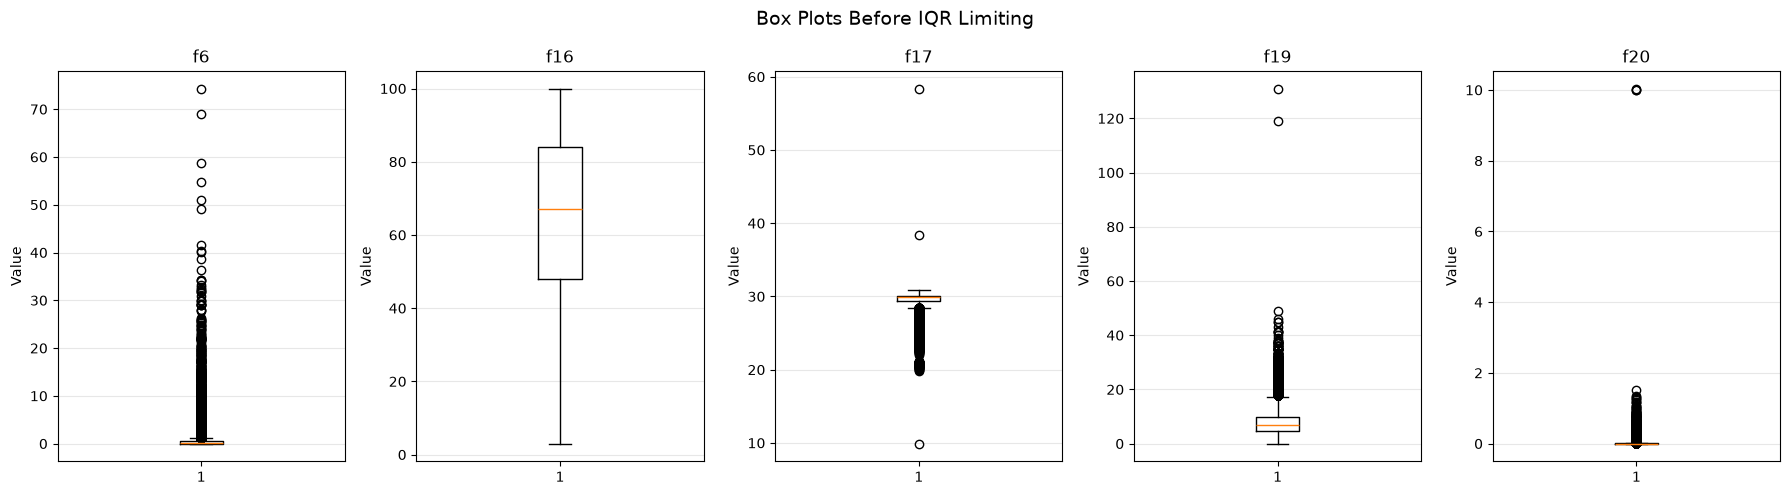

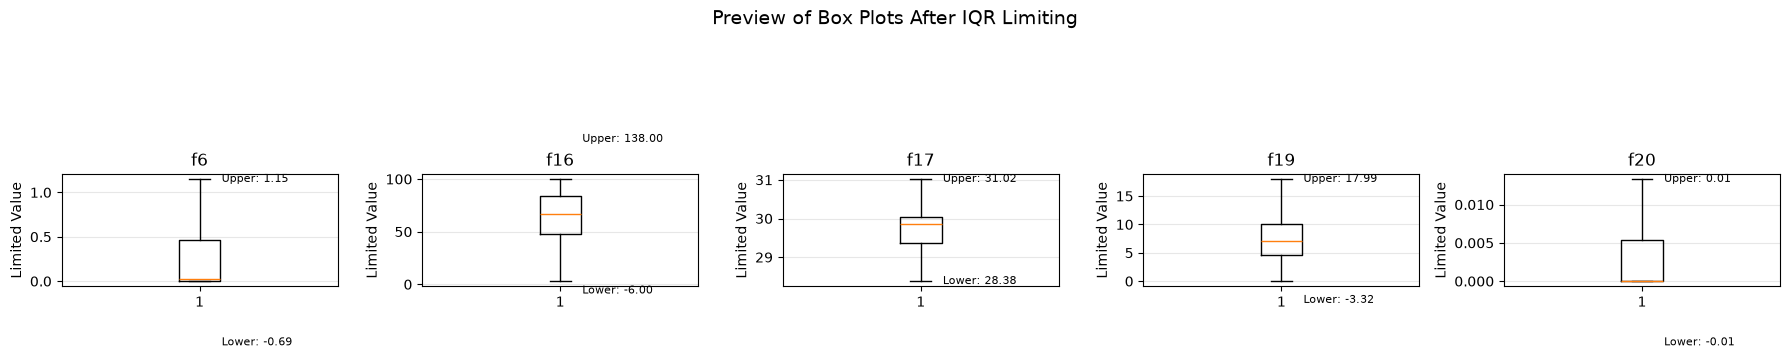

In [33]:
# Features to analyze
iqr_features = ["f6", "f16", "f17", "f19", "f20"]
iqr_multiplier = 1.5

# Store train-based limits
iqr_limits = {}

# Prepare original and preview data
original_boxplot_data = {}
limited_boxplot_data = {}

for feature in iqr_features:
    # Convert values only for analysis
    feature_values = pd.to_numeric(
        train_df[feature],
        errors="coerce"
    ).dropna()

    if feature_values.empty:
        raise ValueError(
            f"No valid numeric values found for '{feature}'."
        )

    # Calculate IQR limits from train
    q1 = feature_values.quantile(0.25)
    q3 = feature_values.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - iqr_multiplier * iqr
    upper_limit = q3 + iqr_multiplier * iqr

    iqr_limits[feature] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit
    }

    original_boxplot_data[feature] = feature_values

    # Preview only; train_df is not changed
    limited_boxplot_data[feature] = feature_values.clip(
        lower=lower_limit,
        upper=upper_limit
    )

# Show calculated limits
iqr_limits_df = pd.DataFrame(iqr_limits).T

display(iqr_limits_df)

# Plot original box plots
fig, axes = plt.subplots(
    1,
    len(iqr_features),
    figsize=(18, 5)
)

for axis, feature in zip(axes, iqr_features):
    axis.boxplot(
        original_boxplot_data[feature],
        showfliers=True
    )

    axis.set_title(feature)
    axis.set_ylabel("Value")
    axis.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Box Plots Before IQR Limiting",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Plot preview after limiting
fig, axes = plt.subplots(
    1,
    len(iqr_features),
    figsize=(18, 5)
)

for axis, feature in zip(axes, iqr_features):
    axis.boxplot(
        limited_boxplot_data[feature],
        showfliers=True
    )

    lower_limit = iqr_limits[feature]["Lower Limit"]
    upper_limit = iqr_limits[feature]["Upper Limit"]

    axis.set_title(feature)
    axis.set_ylabel("Limited Value")
    axis.grid(axis="y", alpha=0.3)

    axis.text(
        1.08,
        upper_limit,
        f"Upper: {upper_limit:.2f}",
        va="center",
        fontsize=8
    )

    axis.text(
        1.08,
        lower_limit,
        f"Lower: {lower_limit:.2f}",
        va="center",
        fontsize=8
    )

fig.suptitle(
    "Preview of Box Plots After IQR Limiting",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [34]:
# Features selected for IQR limiting
features_to_limit = ["f6", "f16", "f17", "f19", "f20"]

datasets = {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}

limiting_summary = []

for dataset_name, dataset in datasets.items():
    for feature in features_to_limit:
        # Convert feature to numeric
        dataset[feature] = pd.to_numeric(
            dataset[feature],
            errors="coerce"
        )

        lower_limit = iqr_limits[feature]["Lower Limit"]
        upper_limit = iqr_limits[feature]["Upper Limit"]

        lower_outlier_count = (
            dataset[feature] < lower_limit
        ).sum()

        upper_outlier_count = (
            dataset[feature] > upper_limit
        ).sum()

        # Limit values instead of removing rows
        dataset[feature] = dataset[feature].clip(
            lower=lower_limit,
            upper=upper_limit
        )

        limiting_summary.append({
            "Dataset": dataset_name,
            "Feature": feature,
            "Lower Limit": lower_limit,
            "Upper Limit": upper_limit,
            "Lower Values Limited": lower_outlier_count,
            "Upper Values Limited": upper_outlier_count,
            "Total Values Limited": (
                lower_outlier_count + upper_outlier_count
            )
        })

# Show limiting summary
limiting_summary = pd.DataFrame(limiting_summary)

display(limiting_summary)

# Verify final ranges
final_ranges = []

for dataset_name, dataset in datasets.items():
    for feature in features_to_limit:
        final_ranges.append({
            "Dataset": dataset_name,
            "Feature": feature,
            "Minimum": dataset[feature].min(),
            "Maximum": dataset[feature].max()
        })

display(pd.DataFrame(final_ranges))

,Dataset,Feature,Lower Limit,Upper Limit,Lower Values Limited,Upper Values Limited,Total Values Limited
0,Train,f6,-0.690000,1.150000,0,8666,8666
1,Train,f16,-6.000000,138.000000,0,0,0
2,Train,f17,28.380000,31.020000,4099,2,4101
3,Train,f19,-3.324670,17.994802,0,2618,2618
4,Train,f20,-0.008001,0.013335,0,5629,5629
5,Validation,f6,-0.690000,1.150000,0,1876,1876
6,Validation,f16,-6.000000,138.000000,0,0,0
7,Validation,f17,28.380000,31.020000,883,1,884
8,Validation,f19,-3.324670,17.994802,0,565,565
9,Validation,f20,-0.008001,0.013335,0,1189,1189


,Dataset,Feature,Minimum,Maximum
0,Train,f6,0.00,1.150000
1,Train,f16,3.00,100.000000
2,Train,f17,28.38,31.020000
3,Train,f19,0.00,17.994802
4,Train,f20,0.00,0.013335
5,Validation,f6,0.00,1.150000
6,Validation,f16,1.00,100.000000
7,Validation,f17,28.38,31.020000
8,Validation,f19,0.00,17.994802
9,Validation,f20,0.00,0.013335


##### Handling Outliers with IQR Capping

We first examined the distributions of `f6`, `f16`, `f17`, `f19`, and `f20` using box plots to identify possible outliers.

Instead of removing the outlier rows, we capped their values using the IQR method. For each feature, the first and third quartiles were calculated only from the training data:

$$
IQR = Q_3 - Q_1
$$

The lower and upper limits were then defined as:

$$
Lower\ Limit = Q_1 - k \times IQR
$$

$$
Upper\ Limit = Q_3 + k \times IQR
$$

Values below the lower limit were replaced with the lower limit, and values above the upper limit were replaced with the upper limit. (k = 1.5)

This approach reduces the effect of extreme values without removing potentially useful accident records. The same limits calculated from the training set were later applied to the validation and test sets to prevent data leakage.

## Standardization

In [35]:
source_mapping = {
    "SOURCE1": 1,
    "SOURCE2": 2,
    "SOURCE3": 3
}

for dataset_name, dataset in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():
    normalized_source = (
        dataset["Source"]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    unexpected_values = sorted(
        set(normalized_source.dropna())
        - set(source_mapping)
    )

    if unexpected_values:
        raise ValueError(
            f"Unexpected Source values in {dataset_name}: "
            f"{unexpected_values}"
        )

    dataset["Source"] = (
        normalized_source
        .map(source_mapping)
        .astype("int8")
    )

In [36]:
columns_to_standardize = [
    "Additional_Lng",
    "f6",
    "f16",
    "f17",
    "f19",
    "f20",
    "Wind_D_Cos",
    "Wind_D_Sin",
    "Record_Delay_Time"
]

# Convert columns to numeric
for dataset in [train_df, validation_df, test_df]:
    dataset[columns_to_standardize] = (
        dataset[columns_to_standardize]
        .apply(pd.to_numeric, errors="coerce")
    )

# Check invalid values
for dataset_name, dataset in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():
    missing_count = (
        dataset[columns_to_standardize]
        .isna()
        .sum()
        .sum()
    )

    if missing_count > 0:
        raise ValueError(
            f"{dataset_name} contains {missing_count} missing "
            "values in columns selected for standardization."
        )

# Fit only on train
numeric_scaler = StandardScaler()

train_df[columns_to_standardize] = (
    numeric_scaler.fit_transform(
        train_df[columns_to_standardize]
    )
)

# Apply train scaler to validation and test
validation_df[columns_to_standardize] = (
    numeric_scaler.transform(
        validation_df[columns_to_standardize]
    )
)

test_df[columns_to_standardize] = (
    numeric_scaler.transform(
        test_df[columns_to_standardize]
    )
)

# Check train statistics
display(
    train_df[columns_to_standardize]
    .agg(["mean", "std"])
    .T
)

,mean,std
Additional_Lng,1.372195e-16,1.000007
f6,-1.341701e-17,1.000007
f16,-5.968539e-16,1.000007
f17,3.367264e-15,1.000007
f19,3.049322e-17,1.000007
f20,-4.553653e-17,1.000007
Wind_D_Cos,-1.626305e-18,1.000007
Wind_D_Sin,4.533325e-17,1.000007
Record_Delay_Time,-8.538100e-18,1.000007


#### temporary part (just to create a pickle file for final.ipynb file to run)

In [ ]:
# # Save all train-based preprocessing parameters for future inference.

# import pickle

# def simplify_imputation_stats(stats):
#     simplified = {}

#     for feature, feature_stats in stats.items():
#         simplified[feature] = {
#             "global_mean": float(feature_stats["global_mean"]),
#             "state_lookup": {
#                 key: float(value)
#                 for key, value in feature_stats["state_lookup"].items()
#             },
#             "city_lookup": {
#                 key: float(value)
#                 for key, value in feature_stats["city_lookup"].items()
#             }
#         }

#     return simplified


# scaler_params = {
#     column: {
#         "mean": float(numeric_scaler.mean_[i]),
#         "scale": float(numeric_scaler.scale_[i])
#     }
#     for i, column in enumerate(columns_to_standardize)
# }


# processing_params = {
#     "environmental_imputation": simplify_imputation_stats(
#         hierarchical_imputation_stats
#     ),

#     "wind_imputation": simplify_imputation_stats(
#         wind_direction_imputation_stats
#     ),

#     "mean_delay": float(mean_delay),

#     "day_night_modes": {
#         key: int(value)
#         for key, value in day_night_modes.items()
#     },

#     "iqr_limits": {
#         feature: {
#             "lower": float(values["Lower Limit"]),
#             "upper": float(values["Upper Limit"])
#         }
#         for feature, values in iqr_limits.items()
#     },

#     "scaler": scaler_params
# }


# with open("to_run_for_new_data/02_processing_params.pkl", "wb") as file:
#     pickle.dump(processing_params, file)


# print("Processing parameters saved successfully.")

Processing parameters saved successfully.


In [38]:
text_columns = [
    "Description",
    "Street",
    "City",
    "County",
    "State",
    "Country"
]

for dataset in [train_df, validation_df, test_df]:
    for column in text_columns:
        dataset[column] = (
            dataset[column]
            .astype("string")
            .str.strip()
            .str.lower()
        )

In [39]:
boolean_columns = [
    f"f{number}"
    for number in range(21, 32)
]

boolean_mapping = {
    "TRUE": 1,
    "FALSE": 0,
    "1": 1,
    "0": 0
}

for dataset_name, dataset in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():
    for column in boolean_columns:
        normalized_values = (
            dataset[column]
            .astype("string")
            .str.strip()
            .str.upper()
        )

        unexpected_values = sorted(
            set(normalized_values.dropna())
            - set(boolean_mapping)
        )

        if unexpected_values:
            raise ValueError(
                f"Unexpected values in {dataset_name} - "
                f"{column}: {unexpected_values}"
            )

        dataset[column] = (
            normalized_values
            .map(boolean_mapping)
            .astype("int8")
        )

# Check final values
for column in boolean_columns:
    print(
        column,
        sorted(train_df[column].unique())
    )

f21 [np.int8(0), np.int8(1)]
f22 [np.int8(0), np.int8(1)]
f23 [np.int8(0), np.int8(1)]
f24 [np.int8(0), np.int8(1)]
f25 [np.int8(0), np.int8(1)]
f26 [np.int8(0), np.int8(1)]
f27 [np.int8(0), np.int8(1)]
f28 [np.int8(0), np.int8(1)]
f29 [np.int8(0), np.int8(1)]
f30 [np.int8(0), np.int8(1)]
f31 [np.int8(0)]


##### Final Feature Transformations

We converted the `Source` categories into numerical values:

- `Source1` → `1`
- `Source2` → `2`
- `Source3` → `3`

The numerical features below were transformed to make their distributions closer to normal and reduce the effect of skewness on model calculations:

`Additional_Lng`, `f6`, `f16`, `f17`, `f19`, `f20`, `Wind_D_Cos`, `Wind_D_Sin`, and `Record_Delay_Time`.

To keep textual values consistent, all characters in `Description`, `Street`, `City`, `County`, `State`, and `Country` were converted to lowercase.

Finally, the Boolean features from `f21` to `f31` were converted into binary values:

- `True` → `1`
- `False` → `0`

In [40]:
# Convert floating-point columns to float32
for dataset in [train_df, validation_df, test_df]:
    float_columns = dataset.select_dtypes(
        include=["float64"]
    ).columns

    dataset[float_columns] = dataset[
        float_columns
    ].astype("float32")

to read data better

## Removing Duplication

In [41]:
# Store initial row counts
rows_before = {
    "Train": len(train_df),
    "Validation": len(validation_df),
    "Test": len(test_df)
}

# Remove duplicates inside each dataset
train_duplicates = train_df.duplicated().sum()
validation_duplicates = validation_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

train_df = (
    train_df
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

validation_df = (
    validation_df
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

test_df = (
    test_df
    .drop_duplicates(keep="first")
    .reset_index(drop=True)
)

# Ensure the same column order
validation_df = validation_df[train_df.columns]
test_df = test_df[train_df.columns]

# Create row hashes
train_hashes = pd.util.hash_pandas_object(
    train_df,
    index=False
)

validation_hashes = pd.util.hash_pandas_object(
    validation_df,
    index=False
)

# Remove validation rows already existing in train
validation_overlap_mask = validation_hashes.isin(
    set(train_hashes)
)

validation_overlap_count = validation_overlap_mask.sum()

validation_df = (
    validation_df
    .loc[~validation_overlap_mask]
    .reset_index(drop=True)
)

# Update valid hashes
validation_hashes = pd.util.hash_pandas_object(
    validation_df,
    index=False
)

known_hashes = (
    set(train_hashes)
    | set(validation_hashes)
)

test_hashes = pd.util.hash_pandas_object(
    test_df,
    index=False
)

# Remove test rows existing in train or validation
test_overlap_mask = test_hashes.isin(known_hashes)
test_overlap_count = test_overlap_mask.sum()

test_df = (
    test_df
    .loc[~test_overlap_mask]
    .reset_index(drop=True)
)

# Show removal summary
duplication_summary = pd.DataFrame({
    "Rows Before": rows_before,
    "Duplicates Inside Dataset": {
        "Train": train_duplicates,
        "Validation": validation_duplicates,
        "Test": test_duplicates
    },
    "Duplicates Across Datasets": {
        "Train": 0,
        "Validation": validation_overlap_count,
        "Test": test_overlap_count
    },
    "Rows After": {
        "Train": len(train_df),
        "Validation": len(validation_df),
        "Test": len(test_df)
    }
})

display(duplication_summary)

# Final check
print("Remaining duplicates:")
print(f"Train: {train_df.duplicated().sum()}")
print(f"Validation: {validation_df.duplicated().sum()}")
print(f"Test: {test_df.duplicated().sum()}")

,Rows Before,Duplicates Inside Dataset,Duplicates Across Datasets,Rows After
Train,69905,41,0,69864
Validation,14978,3,23,14952
Test,14975,3,18,14954


Remaining duplicates:
Train: 0
Validation: 0
Test: 0


In [42]:
train_df.to_csv(
    "csv files/train_processed1.csv",
    index=False,
    encoding="utf-8-sig"
)
test_df.to_csv(
    "csv files/test_processed1.csv",
    index=False,
    encoding="utf-8-sig"
)
validation_df.to_csv(
    "csv files/validation_processed1.csv",
    index=False,
    encoding="utf-8-sig"
)